In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq

# --- parâmetros físicos ---
eps = 8.854187817e-12  # Vacuum permittivity (F/m)
mu = 4 * np.pi * 1e-7  # Vacuum permeability (H/m)
c = 1 / np.sqrt(eps * mu)

# --- domínio ---
a = 0.5
Nx = Ny = 300
dx = dy = 5e-3
cx, cy = Nx//2, Ny//2

dt = 10e-12
Nt = 2000

# --- campos ---
# usa 2 para salvar os valores atuais [0] e futuros [1] para H e E
Ez = np.zeros((2, Nx, Ny))
Hx = np.zeros((2, Nx, Ny))
Hy = np.zeros((2, Nx, Ny))

# mascara para a cavidade
x = np.arange(Nx) * dx
y = np.arange(Ny) * dy
X, Y = np.meshgrid(x, y, indexing='ij')

# circle parameters
R = a               # radius (meters)

# boolean mask: True inside the circle
mask = (X - cx * dx)**2 + (Y - cy * dy)**2 <= R**2

# ponta de prova para coletar pontos para a FFT no centro da cavidade
probe = []

# valores do tempo para salvar os snapshots e montar os heatmaps
n_list = np.linspace(0, Nt//10, 6, dtype=int)  # 6 snapshots ao longo do tempo
Ez_snapshots = []

for n in range(Nt-1):
    # --- fonte (pulso gaussiano no tempo) ---
    t0 = 50
    spread = 15
    source_gaussiano = np.exp(-((n - t0)**2) / spread**2)

    # --- fonte (senoidal no tempo) ---
    frequency = 1e9  # 1 GHz
    source_senoidal = np.sin(2 * np.pi * frequency * n * dt)

    Ez[0, cx, cy] += source_gaussiano

    Hx[1, :, :-1] = Hx[0, :, :-1] - (dt/(mu*dy)) * (
        Ez[0, :, 1:] - Ez[0, :, :-1]
    )

    Hy[1, :-1, :] = Hy[0, :-1, :] + (dt/(mu*dx)) * (
        Ez[0, 1:, :] - Ez[0, :-1, :]
    )

    # --- Update E field (from H at time n+1) ---
    Ez[1, 1:-1, 1:-1] = Ez[0, 1:-1, 1:-1] + (dt/eps) * (
        (Hy[1, 1:-1, 1:-1] - Hy[1, :-2, 1:-1]) / dx -
        (Hx[1, 1:-1, 1:-1] - Hx[1, 1:-1, :-2]) / dy
    )

    # zero nas extremidades e para fora da cavidade (condição de contorno)
    Ez[1][~mask] = 0

    # salva o valor no centro para a FFT
    probe.append(Ez[1, cx + 25, cy + 25])

    # atualiza os campos para o próximo passo
    Hx[0] = Hx[1]
    Hy[0] = Hy[1]
    Ez[0] = Ez[1]

    # salva para os snapshots
    if n in n_list:
        Ez_snapshots.append(Ez[1].copy())



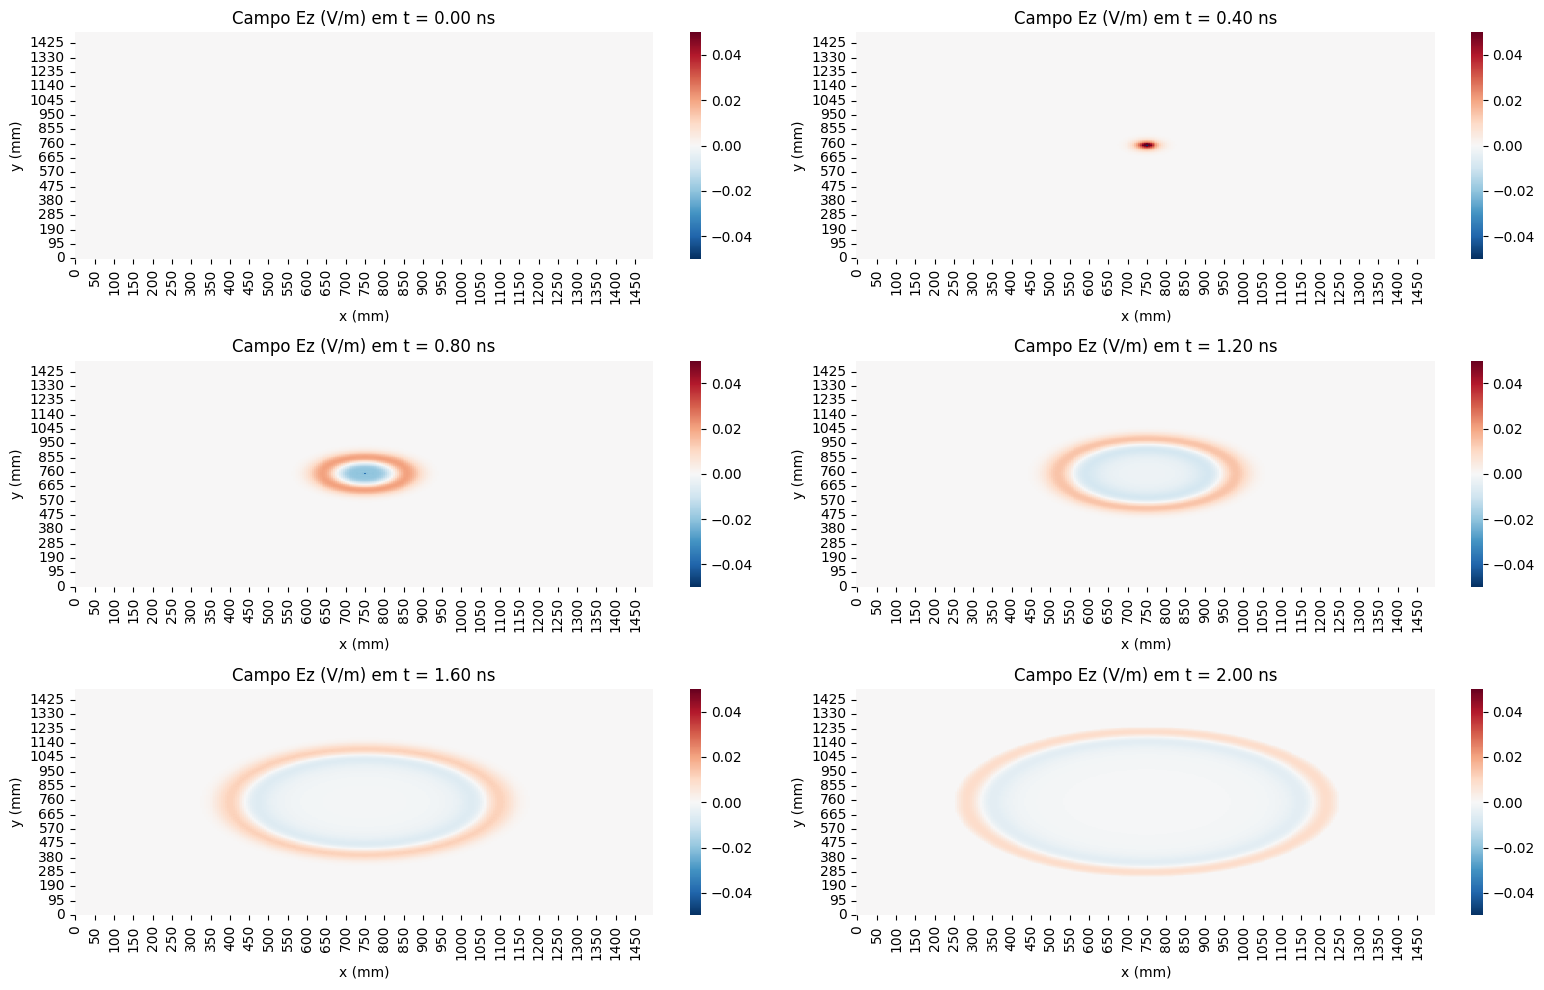

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(16, 10))


for i, ax in enumerate(axes.flat):
    sns.heatmap(Ez_snapshots[i], ax=ax, annot=False, cmap='RdBu_r',vmin=-0.05, vmax=0.05,center=0)
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    ax.set_title(f"Campo Ez (V/m) em t = {n_list[i]*dt*1e9:.2f} ns")

    ticks_x = ax.get_xticks()
    labels_x = [f'{float(label.get_text()) * dx * 1000:.0f}' for label in ax.get_xticklabels()]
    ax.set_xticklabels(labels_x)

    ticks_y = ax.get_yticks()
    labels_y = [f'{float(label.get_text()) * dy * 1000:.0f}' for label in ax.get_yticklabels()]
    ax.set_yticklabels(labels_y)

    ax.invert_yaxis()

plt.tight_layout()
plt.show()

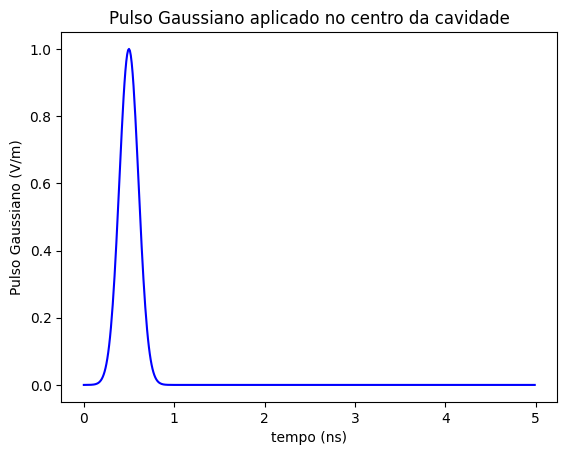

In [10]:
t0 = 50
spread = 15
source_gaussiano = np.exp(-((np.linspace(0,Nt//4, Nt//4) - t0)**2) / spread**2)
tgrid = np.arange(Nt//4) * dt * 1e9  # Convert to nanoseconds

# 2. Create a figure and axis
fig, ax = plt.subplots()

# 3. Plot the data
ax.plot(tgrid,source_gaussiano, label='Pulso Gaussiano (V/m)', color='blue')

# 4. Customize the plot
ax.set_title('Pulso Gaussiano aplicado no centro da cavidade')
ax.set_xlabel('tempo (ns)')
ax.set_ylabel('Pulso Gaussiano (V/m)')

# 5. Display the result
plt.show()

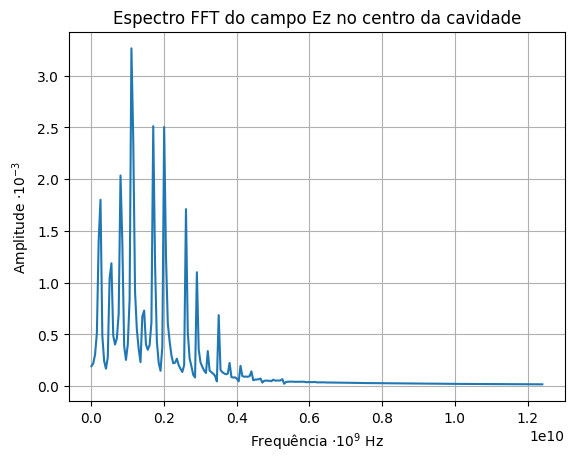

In [ ]:
# 2. Compute the FFT
yf = fft(probe)
xf = fftfreq(len(probe), dt)

# 3. Plot the results (Positive frequencies only)
plt.plot(xf[:len(probe)//8], 1e3 * 2.0/len(probe) * np.abs(yf[:len(probe)//8]))
plt.title("Espectro FFT do campo Ez no centro da cavidade")
plt.xlabel(r"Frequência $\cdot 10^{10}$ Hz")
plt.ylabel(r"Amplitude $\cdot 10^{-3}$")
plt.grid()
plt.show()

In [12]:
print(dt)

print(1 / (c * np.sqrt( (1/dx)**2 + 1/dy**2) ))

1e-11
1.1793271683335256e-11
